In [13]:
import pickle
import os
import pandas as pd
import networkx as nx
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as scp
from scipy.stats import ranksums
import gzip
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [14]:
hippiedata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/hippie/"
genelistdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/"
hisigdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/hisig/"
UCSCtoilpath="/home/ajayasha/scratch/Arvind_umd/UCSC-TOIL/"
ECMprojpath="/home/ajayasha/scratch/Arvind_umd/ECM_proj/"
RCDprojpath="/home/ajayasha/scratch/Arvind_umd/RCD/"
GDCPANCANpath="/home/ajayasha/scratch/Arvind_umd/GDC-PANCAN/"
subtypepath="/home/ajayasha/scratch/Arvind_umd/ECM_proj/subtype_purity/ecm_subtypes/"
stiffnesspath="/home/ajayasha/scratch/Arvind_umd/ECM_proj/stiffness/"

In [77]:
ecm_stiffness=pd.read_csv(stiffnesspath+"ecm_hgdoc_stiffness.txt",sep="\t",index_col=0)

In [79]:
ecm_stiffness

,Tangent modulus (kPa),Relaxation (%)
G#,,
8,0.40,50.0
58,0.60,60.0
102,0.65,60.0
69,0.75,43.0
81,0.88,53.0
30,0.94,63.8
88,0.98,56.0
57,1.13,54.0
94,1.16,49.6


In [80]:
ecm_expression=pd.read_csv(stiffnesspath+"ecm_hgdoc_stiffness_genexp.txt",sep="\t",index_col=0)

In [81]:
matind22=[line.strip() for line in open(stiffnesspath+"matrixindex_stiff.txt")]

In [82]:
matind22ens=ecm_expression[ecm_expression['hgnc_symbol'].isin(matind22)].index.tolist()
with open(stiffnesspath+"matrixindex_stiff_ens.txt","w") as of:
    of.write("matrix_index\t"+"\t".join(matind22ens)+"\n")

In [83]:
matind22ens=ecm_expression[ecm_expression['hgnc_symbol'].isin(matind22)].index.tolist()
print("matrix_index\t"+"\t".join(matind22ens))

matrix_index	ENSG00000038427	ENSG00000060718	ENSG00000091136	ENSG00000100448	ENSG00000105664	ENSG00000108821	ENSG00000110799	ENSG00000112769	ENSG00000115414	ENSG00000131981	ENSG00000135046	ENSG00000135744	ENSG00000135862	ENSG00000142798	ENSG00000154175	ENSG00000163520	ENSG00000164111	ENSG00000164733	ENSG00000168477	ENSG00000197043	ENSG00000204291	ENSG00000206384


In [84]:
from sklearn.linear_model import LinearRegression
import scipy.stats as scp
from scipy.stats import ranksums, wilcoxon
import sklearn as sk
from sklearn.preprocessing import LabelEncoder

In [85]:
testx=pd.read_csv(stiffnesspath+"ssgsea/ecm_hgdoc_stiffness_genexpmatindex.tsv",sep="\t")

In [87]:
ecm_stiffness.index="G"+ecm_stiffness.index.map(str)

In [88]:
testy=ecm_stiffness["Tangent modulus (kPa)"]

In [130]:
df1=pd.concat([ecm_expression.loc[matind22ens].transpose(),testy],join="inner",axis=1)

In [140]:
df1

,ENSG00000038427,ENSG00000060718,ENSG00000091136,ENSG00000100448,ENSG00000105664,ENSG00000108821,ENSG00000110799,ENSG00000112769,ENSG00000115414,ENSG00000131981,...,ENSG00000142798,ENSG00000154175,ENSG00000163520,ENSG00000164111,ENSG00000164733,ENSG00000168477,ENSG00000197043,ENSG00000204291,ENSG00000206384,Tangent modulus (kPa)
G8,6.054564,0.042314,10.239555,2.862308,2.590572,11.947145,8.679552,9.060585,10.280797,7.409812,...,9.287766,8.263851,8.453753,8.857377,8.79938,8.533687,8.136124,7.929815,6.637343,0.40
G10,8.378148,1.717581,9.345853,3.374571,8.173436,15.708185,9.26183,9.364712,11.920388,8.146742,...,10.674367,8.041997,10.084526,8.807688,10.163751,10.721415,8.728763,8.247908,5.944521,1.28
G11,7.442052,1.763015,8.769637,1.327894,3.629202,11.102786,9.633666,7.40492,9.215623,6.832168,...,9.373321,7.174378,8.173942,8.087681,8.947434,7.724854,7.619001,7.738013,2.810323,2.03
G15,6.116371,3.965449,6.331034,-2.458737,2.71361,11.36552,7.778149,5.980628,9.532573,7.163376,...,8.290857,5.284116,6.309696,7.491567,10.11205,5.109898,7.228074,5.929668,0.892477,2.60
G17,8.939699,7.695917,9.337946,2.094269,7.641736,13.51245,8.055963,7.307183,11.812668,6.865718,...,8.951641,6.891218,8.24076,8.298244,9.759052,6.709645,7.573872,6.96061,3.73797,19.13
G29,8.210678,6.437463,7.570743,2.278224,4.032259,13.475426,8.173532,7.308567,10.743945,8.835248,...,8.507589,7.074875,8.34341,9.012431,12.068588,7.52222,7.351532,6.624064,4.910667,3.75
G30,5.941836,1.719938,9.019027,2.550447,0.423041,10.928009,8.591285,9.058957,9.857252,7.665598,...,8.784017,7.294134,7.32027,8.167235,9.958401,7.856861,7.675755,7.583951,4.950354,0.94
G33,7.897486,4.852423,8.584079,1.222476,3.028702,13.930789,8.491836,8.017034,10.143039,6.87619,...,8.932977,7.210849,7.397593,8.045365,8.813327,7.086682,7.794625,7.667271,5.369304,1.76
G42,5.739353,0.530576,10.147631,3.362881,2.40581,11.108141,9.781801,9.359233,9.9354,7.574275,...,10.034729,8.187296,9.008268,8.49102,8.958794,10.212544,8.106911,7.994817,5.658904,1.65
G43,6.478162,-0.475468,8.517412,3.565914,0.667435,9.964952,9.473102,9.403943,8.821114,7.90214,...,9.538761,7.297834,8.767117,8.821003,9.880806,9.234718,8.726257,7.513807,4.676549,1.46


In [157]:
lasso = sk.linear_model.LassoCV(max_iter=10000,cv=6,n_jobs=2)

In [158]:
scores = lasso.fit(df1.loc[:,df1.columns.str.startswith("E")],df1.loc[:,df1.columns.str.startswith("Tangent")].unstack())

In [160]:
scores.score(df1.loc[:,df1.columns.str.startswith("E")],df1.loc[:,df1.columns.str.startswith("Tangent")].unstack())

0.8985830788371647

In [162]:
testx

,G8,G10,G11,G15,G17,G29,G30,G33,G35,G36,...,G85,G88,G92,G93,G94,G102,G124,G136,G138,G144
matrix_index (21g),0.140993,0.580379,-0.151829,-0.443134,0.128208,0.098674,-0.108767,0.109762,0.059012,0.29898,...,0.538566,0.460671,0.36863,-0.079944,-0.038914,-0.058406,-0.315022,-0.568045,-0.157792,0.137991


In [166]:
sns.regplot(x=testx,y=testy)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 35 and the array at index 1 has size 32

In [168]:
testx[test.]testy

G#
G8       0.40
G58      0.60
G102     0.65
G69      0.75
G81      0.88
G30      0.94
G88      0.98
G57      1.13
G94      1.16
G76      1.23
G93      1.28
G10      1.28
G72      1.33
G54      1.43
G43      1.46
G144     1.50
G92      1.53
G42      1.65
G33      1.76
G67      1.77
G11      2.03
G15      2.60
G45      2.89
G29      3.75
G77      3.78
G136     3.81
G85      4.33
G75     10.97
G124    15.90
G17     19.13
G82     33.13
G138    61.90
Name: Tangent modulus (kPa), dtype: float64

In [36]:
ecmmods={}
for line in open(genelistdata+"supmod_ecmcmmed.tsv"):
    line=line.strip()
    cols=line.split("\t")
    ecmmods[cols[0]]=cols[1:]

In [37]:
def jacind(a,b):
    return len(set(a).intersection(set(b)))/len(b)

In [38]:
jacmat={}
for m in ecmmods:
    jacmat[m]=jacind(ecmmods[m],matind22ens)

In [40]:
pd.Series(jacmat).sort_values(ascending=False)

module_128    0.454545
module_232    0.363636
module_145    0.363636
module_55     0.363636
module_0      0.318182
                ...   
module_198    0.000000
module_64     0.000000
module_76     0.000000
module_79     0.000000
module_236    0.000000
Length: 237, dtype: float64

In [123]:
mscores={}
for m in ecmmods:
    if len(ecm_expression.index.intersection(ecmmods[m]))<3:
        continue
    df1=pd.concat([ecm_expression.loc[ecm_expression.index.intersection(ecmmods[m])].transpose(),testy],join="inner",axis=1)
    mscores[m]=cross_val_score(lasso, df1.loc[:,df1.columns.str.startswith("E")],df1["Tangent modulus (kPa)"],cv=cv, scoring='r2', n_jobs=2)

/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.344e-01, tolerance: 4.246e-01
  model = cd_fast.enet_coordinate_descent(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.972e-01, tolerance: 4.246e-01
  model = cd_fast.enet_coordinate_descent(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not c

In [43]:
pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<6].index

Index(['module_0', 'module_9', 'module_12', 'module_15', 'module_16',
       'module_40', 'module_55', 'module_57', 'module_61', 'module_65',
       'module_72', 'module_102', 'module_104', 'module_113', 'module_122',
       'module_128', 'module_131', 'module_136', 'module_143', 'module_145',
       'module_148', 'module_150', 'module_158', 'module_161', 'module_163',
       'module_166', 'module_168', 'module_169', 'module_171', 'module_188',
       'module_209', 'module_219', 'module_222', 'module_232', 'module_236',
       'matind'],
      dtype='object')

In [48]:
pd.DataFrame(mscores).loc[:,pd.DataFrame(mscores).mean()>-6]

,module_0,module_9,module_12,module_15,module_16,module_40,module_55,module_57,module_61,module_65,...,module_168,module_169,module_171,module_188,module_209,module_219,module_222,module_232,module_236,matind
0,-6.526830,-6.643688,-5.018811,-5.213790,-6.503129,-4.355631,-7.156621,-4.641584,-5.098452,-7.724873,...,-6.294521,-6.294521,-2.915617,-4.655148,-3.583474,-2.827458,-4.894475,-3.275399,-3.489953,-6.460354
1,-3.761697,-2.532740,-3.523909,-3.367951,-4.230662,-1.632070,-4.600182,-3.306019,-2.361627,-3.964544,...,-3.529988,-3.529988,-3.117879,-3.807388,-2.634376,-5.084650,-2.021928,-5.072666,-3.717118,-3.749754
2,-3.473135,-5.661306,-7.563162,-5.962940,-2.764941,-6.232891,-2.268777,-4.990456,-4.043418,-3.996823,...,-3.478054,-3.477847,-6.371243,-6.296065,-6.122377,-4.020554,-3.976685,-5.698125,-4.687940,-4.717742
3,-4.337096,-5.755958,-4.544568,-5.421000,-5.455142,-7.003900,-5.668277,-6.664718,-7.827217,-3.842500,...,-5.165008,-5.165008,-5.677243,-5.264902,-5.401160,-6.159527,-8.839008,-3.990467,-8.325809,-4.160765
4,-9.246950,-8.621417,-9.164288,-9.983936,-9.040814,-8.914657,-9.215178,-9.440297,-9.819025,-8.271190,...,-8.265391,-8.265397,-9.191614,-8.969104,-8.483568,-9.541443,-10.032341,-10.118146,-9.356679,-8.687644


In [49]:
jacmat['module_128']

0.45454545454545453

In [50]:
mscoredf=pd.DataFrame(mscores).loc[:,pd.DataFrame(mscores).mean()>-6]

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36]),
 [Text(1, 0, 'module_0'),
  Text(2, 0, 'module_9'),
  Text(3, 0, 'module_12'),
  Text(4, 0, 'module_15'),
  Text(5, 0, 'module_16'),
  Text(6, 0, 'module_40'),
  Text(7, 0, 'module_55'),
  Text(8, 0, 'module_57'),
  Text(9, 0, 'module_61'),
  Text(10, 0, 'module_65'),
  Text(11, 0, 'module_72'),
  Text(12, 0, 'module_102'),
  Text(13, 0, 'module_104'),
  Text(14, 0, 'module_113'),
  Text(15, 0, 'module_122'),
  Text(16, 0, 'module_128'),
  Text(17, 0, 'module_131'),
  Text(18, 0, 'module_136'),
  Text(19, 0, 'module_143'),
  Text(20, 0, 'module_145'),
  Text(21, 0, 'module_148'),
  Text(22, 0, 'module_150'),
  Text(23, 0, 'module_158'),
  Text(24, 0, 'module_161'),
  Text(25, 0, 'module_163'),
  Text(26, 0, 'module_166'),
  Text(27, 0, 'module_168'),
  Text(28, 0, 'module_169'),
  Text(29, 0, 'module_171'),
  Text(30, 

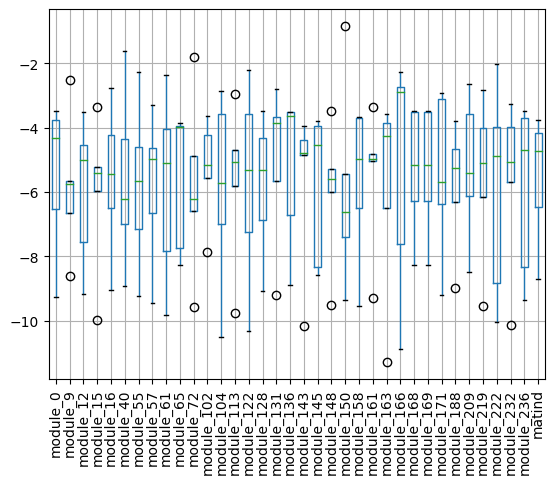

In [51]:
mscoredf.boxplot()
plt.xticks(rotation=90)

In [205]:
pd.Series(jacmat)[pd.Series(jacmat).index.intersection(pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<=5.555252].index)]

module_0      0.086957
module_3      0.074074
module_25     0.172414
module_41     0.000000
module_43     0.000000
module_58     0.181818
module_60     0.090909
module_66     0.173913
module_107    0.090909
dtype: float64

In [191]:
jacmat['module_107']

0.09090909090909091

In [208]:
for c in pd.Series(jacmat).index.intersection(pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<=5.555252].index):
    print(len(ecmmods[c]))

23
27
29
5
5
13
14
23
13


In [210]:
cmmods={}
for line in open(genelistdata+"supmod_cm.tsv"):
    line=line.strip()
    cols=line.split("\t")
    cmmods[cols[0]]=cols[1:]
medmods={}
for line in open(genelistdata+"supmod_med.tsv"):
    line=line.strip()
    cols=line.split("\t")
    medmods[cols[0]]=cols[1:] 

In [212]:
cmjacmat={}
for c in pd.Series(jacmat).index.intersection(pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<=5.555252].index):
    cmjacmat[c]={}
    for d in pd.Series(jacmat).index.intersection(pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<=5.555252].index):
        cmjacmat[c][d]=jacind(cmmods[c],cmmods[d])

In [215]:
ecmjacmat={}
for c in pd.Series(jacmat).index.intersection(pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<=5.555252].index):
    ecmjacmat[c]={}
    for d in pd.Series(jacmat).index.intersection(pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<=5.555252].index):
        ecmjacmat[c][d]=jacind(ecmmods[c],ecmmods[d])

In [217]:
medjacmat={}
for c in pd.Series(jacmat).index.intersection(pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<=5.555252].index):
    medjacmat[c]={}
    for d in pd.Series(jacmat).index.intersection(pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<=5.555252].index):
        medjacmat[c][d]=jacind(medmods[c],medmods[d])

<Axes: >

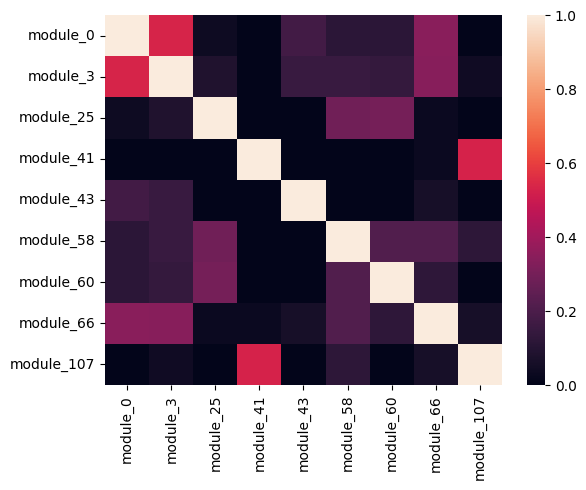

In [214]:
sns.heatmap(pd.DataFrame(cmjacmat))

<Axes: >

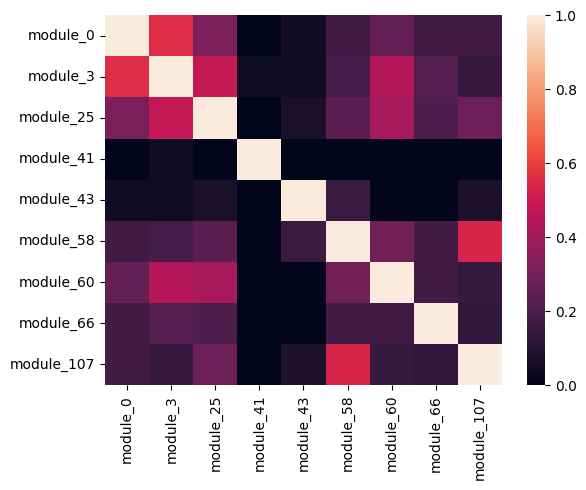

In [216]:
sns.heatmap(pd.DataFrame(ecmjacmat))

<Axes: >

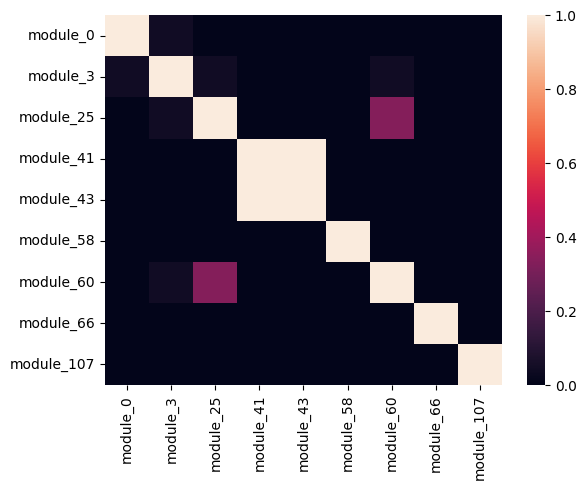

In [218]:
sns.heatmap(pd.DataFrame(medjacmat))

In [220]:
pd.Series(jacmat).index.intersection(pd.DataFrame(mscores).abs().mean()[pd.DataFrame(mscores).abs().mean()<=5.555252].index)

Index(['module_0', 'module_3', 'module_25', 'module_41', 'module_43',
       'module_58', 'module_60', 'module_66', 'module_107'],
      dtype='object')